In [2]:
!pip install imbalanced-learn

In [70]:
!pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
    --------------------------------------- 1.0/56.8 MB 6.6 MB/s eta 0:00:09
   - -------------------------------------- 1.8/56.8 MB 4.9 MB/s eta 0:00:12
   - -------------------------------------- 2.6/56.8 MB 4.5 MB/s eta 0:00:13
   -- ------------------------------------- 3.7/56.8 MB 4.3 MB/s eta 0:00:13
   --- ------------------------------------ 4.5/56.8 MB 4.2 MB/s eta 0:00:13
   --- ------------------------------------ 5.2/56.8 MB 4.2 MB/s eta 0:00:13
   ---- ----------------------------------- 6.0/56.8 MB 4.1 MB/s eta 0:00:13
   ---- ----------------------------------- 6.8/56.8 MB 4.1 MB/s eta 0:00:13
   ----- ---------------------------------- 7.6/56.8 MB 4.1 MB/s eta 0:00:13
   ------ --------------------------------- 8.7/56.8 MB 4.0 MB/s eta 0:00:12
   ------ --------------------------------- 9.4/56.8 MB 4.0 MB/s eta 0:00:12
   ------- -------------------------------- 10.2/56.8 MB 4.0 MB/s eta 0:00:12
   --

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("candidates.csv")
df1 = pd.read_csv("annotations.csv")
df2 = pd.read_csv("sampleSubmission.csv")

In [72]:
dfm = df

In [4]:
df.sample(10)

,seriesuid,coordX,coordY,coordZ,class
254190,1.3.6.1.4.1.14519.5.2.1.6279.6001.238855414831...,67.181756,22.746679,-139.412525,0
52610,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,60.195500,107.479683,-157.682084,0
420820,1.3.6.1.4.1.14519.5.2.1.6279.6001.339142594937...,-30.542627,46.779202,-54.027838,0
532901,1.3.6.1.4.1.14519.5.2.1.6279.6001.910435939545...,-19.899218,-13.938303,-153.841150,0
83336,1.3.6.1.4.1.14519.5.2.1.6279.6001.144438612068...,98.760000,-51.340000,-194.650000,0
142708,1.3.6.1.4.1.14519.5.2.1.6279.6001.177685820605...,-20.073906,54.261717,-224.728489,0
179917,1.3.6.1.4.1.14519.5.2.1.6279.6001.199069398344...,87.610000,39.940000,-107.950000,0
153283,1.3.6.1.4.1.14519.5.2.1.6279.6001.183843376225...,-96.820419,84.478928,-189.015116,0
155723,1.3.6.1.4.1.14519.5.2.1.6279.6001.184412674007...,-39.910000,-34.000000,-218.370000,0
295881,1.3.6.1.4.1.14519.5.2.1.6279.6001.264090899378...,32.297530,43.264742,-245.411364,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551065 entries, 0 to 551064
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   seriesuid  551065 non-null  object 
 1   coordX     551065 non-null  float64
 2   coordY     551065 non-null  float64
 3   coordZ     551065 non-null  float64
 4   class      551065 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 21.0+ MB


In [6]:
df.describe()

,coordX,coordY,coordZ,class
count,551065.000000,551065.000000,551065.000000,551065.000000
mean,-2.005825,8.944721,-157.857852,0.002452
std,71.711619,89.428035,277.212320,0.049453
min,-201.113500,-317.330000,-895.220000,0.000000
25%,-62.126786,-35.780058,-224.790000,0.000000
50%,-17.271143,19.610000,-172.405402,0.000000
75%,61.870000,59.080000,-120.132968,0.000000
max,217.433291,292.380000,1906.140031,1.000000


In [7]:
df['class'].value_counts()

class
0    549714
1      1351
Name: count, dtype: int64

In [8]:
df1.head(10)

,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150
5,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,90.931713,149.027266,-426.544715,18.208570
6,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,89.540769,196.405159,-515.073322,16.381276
7,1.3.6.1.4.1.14519.5.2.1.6279.6001.100953483028...,81.509646,54.957219,-150.346423,10.362321
8,1.3.6.1.4.1.14519.5.2.1.6279.6001.102681962408...,105.055792,19.825260,-91.247251,21.089619
9,1.3.6.1.4.1.14519.5.2.1.6279.6001.104562737760...,-124.834262,127.247155,-473.064479,10.465854


In [9]:
df.head(10)

,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-56.080000,-67.850000,-311.920000,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,53.210000,-244.410000,-245.170000,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.660000,-121.800000,-286.620000,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-33.660000,-72.750000,-308.410000,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-32.250000,-85.360000,-362.510000,0
5,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-26.650000,-203.070000,-165.070000,0
6,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-74.990000,-114.790000,-311.920000,0
7,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-16.140000,-248.610000,-239.550000,0
8,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,135.890000,-141.410000,-252.200000,0
9,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,90.102285,-68.430847,-218.243396,0


In [10]:
df1.describe()

,coordX,coordY,coordZ,diameter_mm
count,1186.000000,1186.000000,1186.000000,1186.000000
mean,-5.067547,8.428113,-160.159029,8.306527
std,84.468115,98.316003,279.829437,4.762033
min,-164.351031,-283.834336,-790.074799,3.253443
25%,-80.909225,-51.549643,-221.197808,5.107177
50%,-32.855132,18.787926,-167.615160,6.433600
75%,76.830069,67.245915,-109.735281,9.696301
max,164.763985,271.405521,1790.494057,32.270030


In [11]:
df.head()

,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-56.08,-67.85,-311.92,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,53.21,-244.41,-245.17,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.66,-121.80,-286.62,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-33.66,-72.75,-308.41,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-32.25,-85.36,-362.51,0


In [12]:
df = df.drop(columns=['seriesuid'])

In [13]:
df.head()

,coordX,coordY,coordZ,class
0,-56.08,-67.85,-311.92,0
1,53.21,-244.41,-245.17,0
2,103.66,-121.80,-286.62,0
3,-33.66,-72.75,-308.41,0
4,-32.25,-85.36,-362.51,0


In [83]:
m = df.loc[df["class"] != 0, ["coordX", "coordY", "coordZ", "class"]]

In [84]:
m.head()

,coordX,coordY,coordZ,class
13,104.164804,-211.685591,-227.011364,1
78,-128.940000,-175.040000,-297.870000,1
1303,70.190000,-140.930000,877.680000,1
3050,89.320000,190.840000,-516.820000,1
3052,94.930000,153.030000,-429.910000,1


In [14]:
X = df[['coordX','coordY','coordZ']]
y = df['class']

In [15]:
X

,coordX,coordY,coordZ
0,-56.08,-67.85,-311.92
1,53.21,-244.41,-245.17
2,103.66,-121.80,-286.62
3,-33.66,-72.75,-308.41
4,-32.25,-85.36,-362.51
...,...,...,...
551060,-55.66,37.24,-110.42
551061,68.40,70.18,-109.72
551062,-82.29,-27.94,-106.92
551063,38.26,83.50,-102.71


In [16]:
y

0         0
1         0
2         0
3         0
4         0
         ..
551060    0
551061    0
551062    0
551063    0
551064    0
Name: class, Length: 551065, dtype: int64

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [18]:
clf1 = RandomForestClassifier(
    n_estimators=100,
    # max_depth=3,
    # min_samples_leaf=5,
    # oob_score=True,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    class_weight='balanced'
)

In [24]:
lr = LogisticRegression()

In [25]:
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pred1 = lr.predict(X_test)

In [27]:
print("accuracy_score:",accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))
print("roc_auc_score:",roc_auc_score(y_test,y_pred1))

accuracy_score: 0.9975502056617469
[[164915      0]
 [   405      0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    164915
           1       0.00      0.00      0.00       405

    accuracy                           1.00    165320
   macro avg       0.50      0.50      0.50    165320
weighted avg       1.00      1.00      1.00    165320

roc_auc_score: 0.5


In [28]:
clf1.fit(X_train,y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 1 of 100
building tree 2 of 100
building tree 9 of 100
building tree 8 of 100
building tree 12 of 100
building tree 3 of 100
building tree 10 of 100
building tree 4 of 100
building tree 11 of 100
building tree 13 of 100
building tree 14 of 100building tree 15 of 100

building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100building tree 30 of 100

building tree 31 of 100


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   12.4s


building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   50.9s finished


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [96]:
y_pred = clf1.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.3s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    1.4s finished


Accuracy: 0.5
Confusion Matrix:
 [[109943      0]
 [109943      0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67    109943
           1       0.00      0.00      0.00    109943

    accuracy                           0.50    219886
   macro avg       0.25      0.50      0.33    219886
weighted avg       0.25      0.50      0.33    219886

ROC-AUC: 0.806347283356278


In [30]:
sm = SMOTE(random_state=42)
X_res,y_res = sm.fit_resample(X,y)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)


In [32]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=2)
clf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 7 of 100building tree 11 of 100
building tree 1 of 100
building tree 3 of 100
building tree 5 of 100
building tree 12 of 100
building tree 10 of 100
building tree 9 of 100
building tree 8 of 100
building tree 6 of 100
building tree 2 of 100
building tree 4 of 100

building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100building tree 20 of 100

building tree 21 of 100
building tree 22 of 100building tree 23 of 100

building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   33.4s


building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100building tree 39 of 100
building tree 40 of 100
building tree 41 of 100

building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.4min finished


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((879542, 3), (219886, 3), (879542,), (219886,))

In [92]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

In [93]:
m.head()

,coordX,coordY,coordZ,class
13,104.164804,-211.685591,-227.011364,1
78,-128.940000,-175.040000,-297.870000,1
1303,70.190000,-140.930000,877.680000,1
3050,89.320000,190.840000,-516.820000,1
3052,94.930000,153.030000,-429.910000,1


In [94]:
print(clf.predict(np.array([[-128.940000,-175.040000,-297.870000]])))

[0]


In [95]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[77395 32548]
 [26962 82981]]
              precision    recall  f1-score   support

           0       0.74      0.70      0.72    109943
           1       0.72      0.75      0.74    109943

    accuracy                           0.73    219886
   macro avg       0.73      0.73      0.73    219886
weighted avg       0.73      0.73      0.73    219886

ROC-AUC: 0.806347283356278


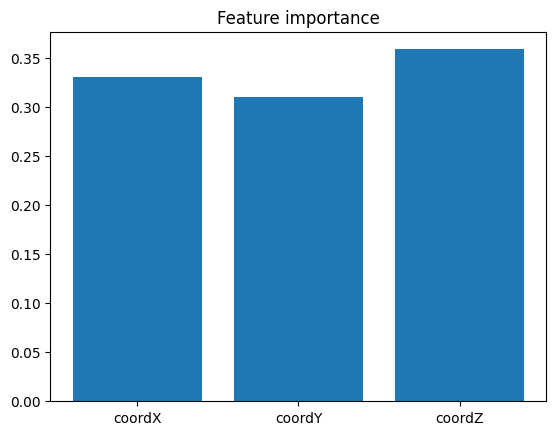

In [36]:
imp = clf.feature_importances_
features = X.columns

plt.bar(features,imp)
plt.title("Feature importance")
plt.show()

In [ ]:
# print("Before SMOTE:", np.bincount(y_train))
# print("After SMOTE:", np.bincount(y_res))

In [37]:
from sklearn.linear_model import LogisticRegression

In [56]:
lr1 = LogisticRegression(penalty='l2',max_iter=5000,l1_ratio=0.6)

In [57]:
lr1.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [58]:
y_pred11 = lr1.predict(X_test)

In [88]:
print(lr1.predict(np.array([[-128.940000,-175.040000,-297.870000]])))

[0]


In [59]:
print("accuracy_score:",accuracy_score(y_test,y_pred11))
print(confusion_matrix(y_test,y_pred11))
print(classification_report(y_test,y_pred11))
print("roc_auc_score:",roc_auc_score(y_test,y_pred11))

accuracy_score: 0.504784297317701
[[52711 57232]
 [51659 58284]]
              precision    recall  f1-score   support

           0       0.51      0.48      0.49    109943
           1       0.50      0.53      0.52    109943

    accuracy                           0.50    219886
   macro avg       0.50      0.50      0.50    219886
weighted avg       0.50      0.50      0.50    219886

roc_auc_score: 0.504784297317701


In [60]:
from sklearn.model_selection import cross_val_score

In [61]:
scores = cross_val_score(lr, X, y, cv=5, scoring='roc_auc')

In [62]:
scores.mean()

np.float64(0.47626579854757567)

In [71]:
import xgboost as xgb

In [65]:
from sklearn.preprocessing import StandardScaler

In [66]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [74]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"Negatives: {neg}, Positives: {pos}, scale_pos_weight={scale_pos_weight:.2f}")

Negatives: 439771, Positives: 439771, scale_pos_weight=1.00


In [75]:
clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

# 5. Evaluation
y_pred = clf.predict(X_test)
y_pred_prob = clf.predict_proba(X_test)[:, 1]

In [76]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.7293597591479221
Confusion Matrix:
 [[77395 32548]
 [26962 82981]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.70      0.72    109943
           1       0.72      0.75      0.74    109943

    accuracy                           0.73    219886
   macro avg       0.73      0.73      0.73    219886
weighted avg       0.73      0.73      0.73    219886

ROC-AUC: 0.806347283356278
